In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

# Find the project root (the nearest ancestor that contains `src`) and add it to sys.path
cwd = Path.cwd()
project_root = cwd
for _ in range(6):
    if (project_root / "src").exists():
        break
    if project_root.parent == project_root:
        break
    project_root = project_root.parent
else:
    project_root = cwd

proj_path = str(project_root.resolve())
if proj_path not in sys.path:
    # Insert at front so local packages take precedence
    sys.path.insert(0, proj_path)

import aerosandbox.numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src.airfoil.compute_airfoil_quality import compute_airfoil_quality, QualityError

import aerosandbox as asb
from aerosandbox import Airfoil
from src.airfoil import airfoil_modifications

import plotly.express as px

import src.plotting as plotting

I0000 00:00:1778724383.932016   15947 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778724383.932515   15947 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778724384.100691   15947 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778724385.227908   15947 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_E

In [2]:
airfoil = Airfoil(name="s1223")
airfoil = airfoil.repanel(n_points_per_side=35)
# airfoil.draw(show=False, fill=False)
airfoil.draw(draw_markers=True, backend="plotly", save_path="./images/s1223_plotly.pdf")

Gráfico salvo com sucesso em: ./images/s1223_plotly.pdf


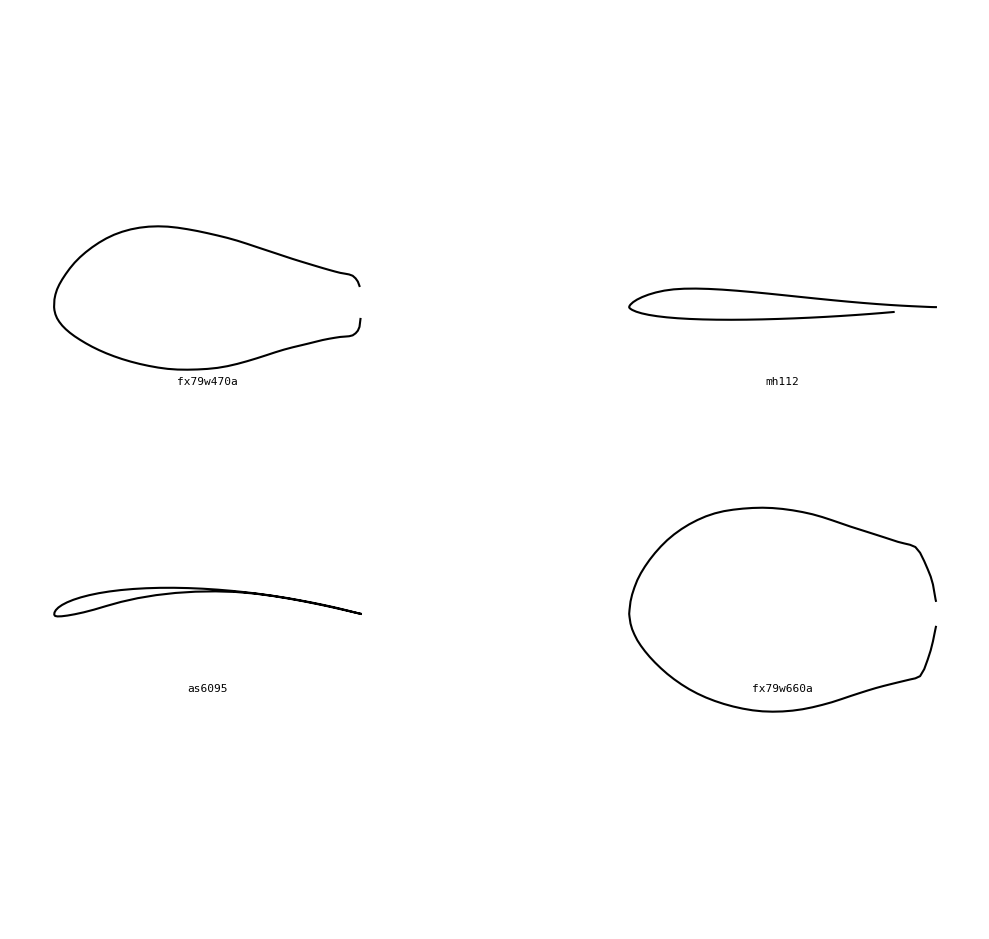

In [3]:
removed_airfoils = ["fx79w470a", "mh112", "as6095", "fx79w660a"]

airfoils = [asb.Airfoil(name) for name in removed_airfoils]

plotting.plot_airfoil_list(airfoils, color="black", save_path="./images", labels=removed_airfoils, filename="removed_airfoils.png")

In [29]:
from pathlib import Path
import importlib

import pandas as pd
import plotly.graph_objects as go
import plotly.io._kaleido as plotly_kaleido

# 1. Resolução de caminhos do projeto
cwd = Path.cwd()
project_root = cwd
for _ in range(6):
    if (project_root / "data").exists() and (project_root / "src").exists():
        break
    if project_root.parent == project_root:
        break
    project_root = project_root.parent

csv_path = project_root / "data" / "wandb" / "compression" / "compression_kl_vs_geo.csv"
output_dir = project_root / "images"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "compression_kl_vs_geo.png"

# 2. Leitura e pré-processamento dos dados
df = pd.read_csv(csv_path)
df = df.rename(columns={"epoch_kl_loss": "kl_loss", "val_geo_mae": "geo_mae"})
df = df[["Name", "kl_loss", "geo_mae"]].dropna().copy()
df["run_label"] = df["Name"].str.split("-").str[-1]

# 3. Cálculo da Fronteira de Pareto (Minimização bi-objetivo)
pareto_mask = []
for _, row in df.iterrows():
    dominated = (
        (df["kl_loss"] <= row["kl_loss"])
        & (df["geo_mae"] <= row["geo_mae"])
        & ((df["kl_loss"] < row["kl_loss"]) | (df["geo_mae"] < row["geo_mae"]))
    ).any()
    pareto_mask.append(not dominated)

df["is_pareto"] = pareto_mask
pareto_df = df[df["is_pareto"]].sort_values(["kl_loss", "geo_mae"]).copy()

# 4. Cálculo do Score de Trade-off (Distância Euclidiana Normalizada)
normalized = df[["kl_loss", "geo_mae"]].copy()
for column in normalized.columns:
    col_min = normalized[column].min()
    col_max = normalized[column].max()
    normalized[column] = 0.0 if col_max == col_min else (normalized[column] - col_min) / (col_max - col_min)

df["tradeoff_score"] = (normalized["kl_loss"] ** 2 + normalized["geo_mae"] ** 2) ** 0.5

# 5. Seleção do melhor modelo DENTRO da região viável
valid_mask = (df["kl_loss"] < 1.0) & (df["geo_mae"] < 0.002)
best_idx = df.loc[valid_mask, "tradeoff_score"].idxmin()
best_row = df.loc[best_idx]

# 6. Configurações visuais do gráfico
slate_dark = "#2F4F4F"
slate_mid = "#708090"
slate_light = "rgba(112, 128, 144, 0.42)"
highlight_green = "rgba(46, 204, 113, 0.12)" # Cor da região viável

fig = go.Figure()

# Adiciona o retângulo indicando a região de aprovação (nascendo do zero matemático)
fig.add_shape(
    type="rect",
    x0=0,
    y0=0,
    x1=1.0,
    y1=0.002,
    fillcolor=highlight_green,
    line=dict(width=0),
    layer="below"
)

# Adiciona as linhas pontilhadas para demarcar os limites de corte
fig.add_vline(
    x=1.0, 
    line_dash="dot", 
    line_color=slate_dark, 
    opacity=0.6,
    annotation_text="KL Máx = 1.0",
    annotation_position="top left"
)
fig.add_hline(
    y=0.002, 
    line_dash="dot", 
    line_color=slate_dark, 
    opacity=0.6,
    annotation_text="MAE Máx = 0.002",
    annotation_position="bottom right"
)

# Plota todos os modelos
fig.add_trace(
    go.Scatter(
        x=df["kl_loss"],
        y=df["geo_mae"],
        mode="markers",
        name="Modelos",
        text=df["run_label"],
        customdata=df[["Name", "tradeoff_score"]],
        marker=dict(
            size=10,
            color=slate_mid,
            opacity=0.8,
            line=dict(color=slate_dark, width=1),
        ),
        hovertemplate=(
            "<b>%{text}</b><br>"
            "KL loss: %{x:.4f}<br>"
            "Geo MAE: %{y:.6f}<br>"
            "Score: %{customdata[1]:.4f}<extra></extra>"
        ),
    )
)

# Plota a linha da Fronteira de Pareto
fig.add_trace(
    go.Scatter(
        x=pareto_df["kl_loss"],
        y=pareto_df["geo_mae"],
        mode="lines",
        name="Pareto",
        line=dict(color=slate_dark, width=2.5, dash="dash"),
        hoverinfo="skip",
    )
)

# Plota o destaque para o modelo escolhido
fig.add_trace(
    go.Scatter(
        x=[best_row["kl_loss"]],
        y=[best_row["geo_mae"]],
        mode="markers+text",
        name="Escolhido",
        text=[best_row["run_label"]],
        textposition="top right", 
        marker=dict(
            size=16,
            color=slate_dark,
            symbol="diamond",
            line=dict(color="white", width=2),
        ),
        hovertemplate=(
            "<b>%{text}</b><br>"
            "KL loss: %{x:.4f}<br>"
            "Geo MAE: %{y:.6f}<extra></extra>"
        ),
    )
)

# Configurações de layout gerais
fig.update_layout(
    template="plotly_white",
    width=980,
    height=640,
    font=dict(family="Arial", size=14, color=slate_dark),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    margin=dict(l=70, r=40, t=90, b=70),
    plot_bgcolor="white",
    paper_bgcolor="white",
)

# Configurações do Eixo X (com a trava de visão ajustada para folga antes de 0.8)
fig.update_xaxes(
    title=dict(text="<i>L</i><sub>KL</sub>"),
    showline=True,
    linewidth=1,
    linecolor=slate_dark,
    gridcolor="rgba(47, 79, 79, 0.10)",
    zeroline=False,
    range=[0.75, df["kl_loss"].max() + 0.02] 
)

# Configurações do Eixo Y
fig.update_yaxes(
    title=dict(text="MAE<sub>geo</sub>"),
    showline=True,
    linewidth=1,
    linecolor=slate_dark,
    gridcolor="rgba(47, 79, 79, 0.10)",
    zeroline=False,
    range=[df["geo_mae"].min() - 0.00005, df["geo_mae"].max() + 0.00005]
)

# 7. Relatório no console e Exportação da imagem
print(
    "Modelo escolhido:",
    best_row["Name"],
    f"| KL loss = {best_row['kl_loss']:.4f}",
    f"| geo_mae = {best_row['geo_mae']:.6f}",
)

importlib.reload(plotly_kaleido)
fig.write_image(output_path, width=980, height=640, scale=300 / 96)
print(f"Imagem salva em: {output_path}")

fig.show()

Modelo escolhido: CSTVAE_20260512-002232 | KL loss = 0.9609 | geo_mae = 0.001454
Imagem salva em: /home/matsouto/Documents/py/AeroGen/images/compression_kl_vs_geo.png


In [15]:

from pathlib import Path
import importlib
import re

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io._kaleido as plotly_kaleido
import plotly.colors

# Descoberta da raiz do projeto
cwd = Path.cwd()
project_root = cwd
for _ in range(6):
    if (project_root / "data").exists() and (project_root / "src").exists():
        break
    if project_root.parent == project_root:
        break
    project_root = project_root.parent

# Diretório de saída das imagens e dos CSVs
output_dir = project_root / "images"
output_dir.mkdir(parents=True, exist_ok=True)
csv_dir = project_root / "data" / "wandb" / "compression"

# Cores base e grid
slate_dark = "#2F4F4F"
grid_color = "rgba(47, 79, 79, 0.10)"

# Lista de arquivos e respectivos rótulos do eixo Y
arquivos = [
    ("compression_total_loss.csv", "Total Loss"),
    ("compression_kl_loss.csv", "<i>L</i><sub>KL</sub>"),
    ("compression_beta.csv", "Beta"),
    ("compression_val_mae.csv", "MAE<sub>cst</sub>"),
    ("compression_geo_mae.csv", "MAE<sub>geo</sub>"),
    ("compression_active_units.csv", "Unidades ativas")
]

# 1. Identificar todas as runs únicas para criar um gradiente de cores consistente
runs_unicas = set()
dataframes = {}

for arquivo, _ in arquivos:
    csv_path = csv_dir / arquivo
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        dataframes[arquivo] = df
        for col in df.columns:
            if col != "Step" and "__MIN" not in col and "__MAX" not in col:
                match = re.search(r'-(\d+)\s*-', col)
                if match:
                    runs_unicas.add(match.group(1))
                else:
                    runs_unicas.add(col)

runs_unicas = sorted(list(runs_unicas))
num_runs = len(runs_unicas)

# Gerar gradiente de cores estilo W&B (Viridis)
if num_runs > 1:
    escala_cores = plotly.colors.sample_colorscale(
        "Viridis", [i / (num_runs - 1) for i in range(num_runs)]
    )
else:
    escala_cores = [slate_dark]

mapa_cores = dict(zip(runs_unicas, escala_cores))

# 2. Criar a figura com 2 linhas e 3 colunas
fig = make_subplots(rows=2, cols=3, horizontal_spacing=0.08, vertical_spacing=0.12)

runs_na_legenda = set()

# 3. Preencher os subplots
for idx, (arquivo, ylabel) in enumerate(arquivos):
    linha = (idx // 3) + 1
    coluna = (idx % 3) + 1
    
    if arquivo not in dataframes:
        print(f"Arquivo não encontrado: {arquivo}")
        continue
        
    df = dataframes[arquivo]
    
    for col in df.columns:
        if col != "Step" and "__MIN" not in col and "__MAX" not in col:
            match = re.search(r'-(\d+)\s*-', col)
            nome_legenda = match.group(1) if match else col
            
            # Adicionar à legenda apenas se for a primeira vez que a run aparece
            mostrar_legenda = nome_legenda not in runs_na_legenda
            if mostrar_legenda:
                runs_na_legenda.add(nome_legenda)
                
            fig.add_trace(
                go.Scatter(
                    x=df["Step"], 
                    y=df[col], 
                    mode="lines", 
                    name=nome_legenda,
                    line=dict(color=mapa_cores.get(nome_legenda, "#000"), width=2),
                    showlegend=mostrar_legenda,
                    legendgroup=nome_legenda
                ),
                row=linha, col=coluna
            )
            
    # Configuração do eixo X para o subplot atual
    fig.update_xaxes(
        title=dict(text="Épocas"),
        showline=True,
        linewidth=1,
        linecolor=slate_dark,
        gridcolor=grid_color,
        zeroline=False,
        row=linha, col=coluna
    )
    
    # Configuração do eixo Y para o subplot atual
    fig.update_yaxes(
        title=dict(text=ylabel),
        showline=True,
        linewidth=1,
        linecolor=slate_dark,
        gridcolor=grid_color,
        zeroline=False,
        row=linha, col=coluna
    )

# 4. Ajustes finais de layout (sem título global e com legenda unificada)
fig.update_layout(
    template="plotly_white",
    width=1400,
    height=750,
    font=dict(family="Arial", size=14, color=slate_dark),
    legend=dict(
        orientation="h", 
        yanchor="bottom", 
        y=1.05, 
        xanchor="center", 
        x=0.5, 
        title="Run"
    ),
    margin=dict(l=60, r=40, t=100, b=60),
    plot_bgcolor="white",
    paper_bgcolor="white",
)

# 5. Salvar e exibir a imagem unificada
output_path = output_dir / "compression_combined_metrics.png"

importlib.reload(plotly_kaleido)
fig.write_image(output_path, width=1400, height=750, scale=300 / 96)
print(f"Imagem unificada salva em: {output_path}")

fig.show()

Imagem unificada salva em: /home/matsouto/Documents/py/AeroGen/images/compression_combined_metrics.png


In [3]:
from pathlib import Path
import importlib

import pandas as pd
import plotly.graph_objects as go
import plotly.io._kaleido as plotly_kaleido

cwd = Path.cwd()
project_root = cwd
for _ in range(6):
    if (project_root / "data").exists() and (project_root / "src").exists():
        break
    if project_root.parent == project_root:
        break
    project_root = project_root.parent

csv_path = project_root / "data" / "wandb" / "compression" / "compression_geo_dim.csv"
output_dir = project_root / "images"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "compression_geo_dim.png"

df = pd.read_csv(csv_path)
df = df.rename(columns={"val_geo_mae": "geo_mae"})
df = df[["Name", "latent_dim", "geo_mae"]].dropna().copy()
df["latent_dim"] = pd.to_numeric(df["latent_dim"])
df["geo_mae"] = pd.to_numeric(df["geo_mae"])
df = df.sort_values("latent_dim").reset_index(drop=True)

chosen_dim = 10
chosen_row = df.loc[df["latent_dim"] == chosen_dim].iloc[0]

slate_dark = "#2F4F4F"
slate_mid = "#708090"
highlight_green = "#4ccd77"

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df["latent_dim"],
        y=df["geo_mae"],
        mode="lines+markers",
        name="Modelos",
        text=df["Name"],
        line=dict(color=slate_mid, width=2.5),
        marker=dict(
            size=10,
            color=slate_mid,
            opacity=0.9,
            line=dict(color=slate_dark, width=1),
        ),
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Latent dim: %{x}<br>"
            "Geo MAE: %{y:.6f}<extra></extra>"
        ),
    )
)

fig.add_trace(
    go.Scatter(
        x=[chosen_row["latent_dim"]],
        y=[chosen_row["geo_mae"]],
        mode="markers",
        name="Escolhido",
        marker=dict(
            size=16,
            color=slate_dark,
            symbol="diamond",
            line=dict(color="white", width=2),
        ),
        hovertemplate=(
            "<b>Modelo escolhido</b><br>"
            "Latent dim: %{x}<br>"
            "Geo MAE: %{y:.6f}<extra></extra>"
        ),
    )
)

fig.update_layout(
    template="plotly_white",
    width=980,
    height=640,
    font=dict(family="Arial", size=14, color=slate_dark),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    margin=dict(l=70, r=40, t=90, b=70),
    plot_bgcolor="white",
    paper_bgcolor="white",
)

fig.update_xaxes(
    title=dict(text="Z<sub>dim</sub>"),
    showline=True,
    linewidth=1,
    linecolor=slate_dark,
    gridcolor="rgba(47, 79, 79, 0.10)",
    zeroline=False,
    dtick=1,
    range=[df["latent_dim"].min() - 0.3, df["latent_dim"].max() + 0.3]
)

fig.update_yaxes(
    title=dict(text="MAE<sub>geo</sub>"),
    showline=True,
    linewidth=1,
    linecolor=slate_dark,
    gridcolor="rgba(47, 79, 79, 0.10)",
    zeroline=False,
    range=[df["geo_mae"].min() - 0.0001, df["geo_mae"].max() + 0.00015]
)

print(
    "Modelo escolhido:",
    chosen_row["Name"],
    f"| latent_dim = {int(chosen_row['latent_dim'])}",
    f"| geo_mae = {chosen_row['geo_mae']:.6f}",
)

importlib.reload(plotly_kaleido)
fig.write_image(output_path, width=980, height=640, scale=300 / 96)
print(f"Imagem salva em: {output_path}")

fig.show()

Modelo escolhido: CSTVAE_20260518-224036 | latent_dim = 10 | geo_mae = 0.001466
Imagem salva em: /home/matsouto/Documents/py/AeroGen/images/compression_geo_dim.png


In [7]:
from pathlib import Path
import importlib

import pandas as pd
import plotly.graph_objects as go
import plotly.io._kaleido as plotly_kaleido

cwd = Path.cwd()
project_root = cwd
for _ in range(6):
    if (project_root / "data").exists() and (project_root / "src").exists():
        break
    if project_root.parent == project_root:
        break
    project_root = project_root.parent

output_dir = project_root / "images"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "vod_relative_comparison.png"

my_results = {"CST-VAE": 0.992}
papers_result = [{"plain-GAN": 0.0872}, {"CST-WGAN": 0.933}, {"CST-SNGAN": 3.575}]

records = [{"model": model, "vod_relativo": value, "source": "mine"} for model, value in my_results.items()]
for result in papers_result:
    for model, value in result.items():
        records.append({"model": model, "vod_relativo": value, "source": "paper"})

df = pd.DataFrame(records).sort_values("vod_relativo", ascending=True).reset_index(drop=True)

slate_dark = "#2F4F4F"
highlight_green = "#2D6A4F"
grid_color = "rgba(47, 79, 79, 0.10)"
reference_gray = "rgba(107, 114, 128, 0.8)"

df["color"] = df["source"].map({"mine": highlight_green, "paper": reference_gray})

fig = go.Figure(
    go.Bar(
        x=df["vod_relativo"],
        y=df["model"],
        orientation="h",
        marker=dict(
            color=df["color"],
            line=dict(color=slate_dark, width=1),
        ),
        text=df["vod_relativo"],
        texttemplate="%{text:.3f}",
        textposition="outside",
        hovertemplate=(
            "<b>%{y}</b><br>"
            "VOD relativo: %{x:.3f}<extra></extra>"
        ),
    )
)

fig.add_vline(
    x=1,
    line_dash="dash",
    line_color=reference_gray,
    line_width=2,
)

fig.update_layout(
    template="plotly_white",
    width=980,
    height=520,
    font=dict(family="Arial", size=14, color=slate_dark),
    margin=dict(l=120, r=60, t=50, b=70),
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False,
    bargap=0.28,
)

fig.update_xaxes(
    title=dict(text="VOD<sub>rel</sub>"),
    showline=True,
    linewidth=1,
    linecolor=slate_dark,
    gridcolor=grid_color,
    zeroline=False,
    range=[0, df["vod_relativo"].max() * 1.12],
)

fig.update_yaxes(
    showline=True,
    linewidth=1,
    linecolor=slate_dark,
    gridcolor="rgba(0, 0, 0, 0)",
    zeroline=False,
)

importlib.reload(plotly_kaleido)
fig.write_image(output_path, width=980, height=520, scale=300 / 96)
print(f"Imagem salva em: {output_path}")

fig.show()

Imagem salva em: /home/matsouto/Documents/py/AeroGen/images/vod_relative_comparison.png


In [10]:
from pathlib import Path
import importlib

import pandas as pd
import plotly.graph_objects as go
import plotly.io._kaleido as plotly_kaleido

cwd = Path.cwd()
project_root = cwd
for _ in range(6):
    if (project_root / "data").exists() and (project_root / "src").exists():
        break
    if project_root.parent == project_root:
        break
    project_root = project_root.parent

output_dir = project_root / "images"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "rd_comparison.png"

results = [
    {"model": "CST-WGAN)", "rd": 1.782, "source": "paper"},
    {"model": "CST-SNGAN", "rd": 1.602, "source": "paper"},
    {"model": "CST-VAE", "rd": 1.016, "source": "mine"},
]

df = pd.DataFrame(results).sort_values("rd", ascending=True).reset_index(drop=True)

slate_dark = "#2F4F4F"
highlight_green = "#2D6A4F"
grid_color = "rgba(47, 79, 79, 0.10)"
reference_gray = "rgba(107, 114, 128, 0.8)"

df["color"] = df["source"].map({"mine": highlight_green, "paper": reference_gray})

fig = go.Figure(
    go.Bar(
        x=df["rd"],
        y=df["model"],
        orientation="h",
        marker=dict(
            color=df["color"],
            line=dict(color=slate_dark, width=1),
        ),
        text=df["rd"],
        texttemplate="%{text:.3f}",
        textposition="outside",
        hovertemplate=(
            "<b>%{y}</b><br>"
            "RD: %{x:.3f}<extra></extra>"
        ),
    )
)

fig.add_vline(
    x=1,
    line_dash="dash",
    line_color=reference_gray,
    line_width=2,
)

fig.update_layout(
    template="plotly_white",
    width=980,
    height=480,
    font=dict(family="Arial", size=14, color=slate_dark),
    margin=dict(l=170, r=60, t=50, b=70),
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False,
    bargap=0.28,
)

fig.update_xaxes(
    title=dict(text="RD"),
    showline=True,
    linewidth=1,
    linecolor=slate_dark,
    gridcolor=grid_color,
    zeroline=False,
    range=[0, df["rd"].max() * 1.12],
)

fig.update_yaxes(
    showline=True,
    linewidth=1,
    linecolor=slate_dark,
    gridcolor="rgba(0, 0, 0, 0)",
    zeroline=False,
)

importlib.reload(plotly_kaleido)
fig.write_image(output_path, width=980, height=480, scale=300 / 96)
print(f"Imagem salva em: {output_path}")

fig.show()

Imagem salva em: /home/matsouto/Documents/py/AeroGen/images/rd_comparison.png
